In [16]:
using LinearAlgebra
using SpecialFunctions
include("sub_elliptical.jl")
using LaTeXStrings
using LinearAlgebra

In [100]:
v = 0.99
A = sub_ellipse(v,3pi/2,3pi/2,10pi,10pi,300,false,true)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:  1265998
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:   181202
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:   181202
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0000000e+00 1.45e+01 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [-0.034663297532616336 -0.03483124997724312 … 0.00023893970678514308 -7.813763274392045e-5; -0.03824625495746208 -0.03840752615894203 … 0.0023993363300558535 0.0003218452072735554; … ; -0.03824535053679178 -0.0384075201092936 … 0.0023994099748276716 0.0003213366100961179; -0.034662861643478454 -0.03483130236935508 … 0.00023892149093114254 -7.82276087614095e-5], [-0.03770386535995065 -0.03770145601007456 … 0.0002315291762543109 8.328504422585627e-5; -0.03391594876753629 -0.033871782225997 … -0.002131621285670701 0.000490832738111225; … ; -0.033915763753340364 -0.03387186509375404 … -0.0021314867738360093 0.0004913293890807351; -0.03770380738562747 -0.03770152039256893 … 0.00023154367064873171 8.323315482898844e-5], 0.10471975511965977, 127, 175, 127, 175, 0.10471975511965977, -0.43099113134136635, true, false, 0.590869804155

In [110]:
mod_grad_real = zeros(301,301)
mod_grad_imag = zeros(301,301)
mod_grad = zeros(301,301)
mod_real = zeros(301,301)
mod_imag = zeros(301,301)
mod_full = zeros(301,301)
for xi in 2:300
    for yi in 2:300
        hx_r = first_centred_x(A[3],A[5],yi,xi)
        hy_r = first_centred_y(A[3],A[5],yi,xi)
        hx_i = first_centred_x(A[4],A[5],yi,xi)
        hy_i = first_centred_y(A[4],A[5],yi,xi)
        mod_grad_real[yi,xi] = sqrt(hx_r^2+hy_r^2)
        mod_grad_imag[yi,xi] = sqrt(hx_i^2+hy_i^2)
        mod_grad[yi,xi] = sqrt(hx_r^2+hx_i^2+hy_r^2+hy_i^2)
        mod_real[yi,xi] = abs(A[3][yi,xi])
        mod_imag[yi,xi] = abs(A[4][yi,xi])
        mod_full[yi,xi] = sqrt(A[3][yi,xi]^2+A[4][yi,xi]^2)
    end
end

In [102]:
theme(:vibrant)

In [111]:
x_vals = -10pi/2:A[5]:10pi/2

-15.707963267948966:0.10471975511965977:15.707963267948966

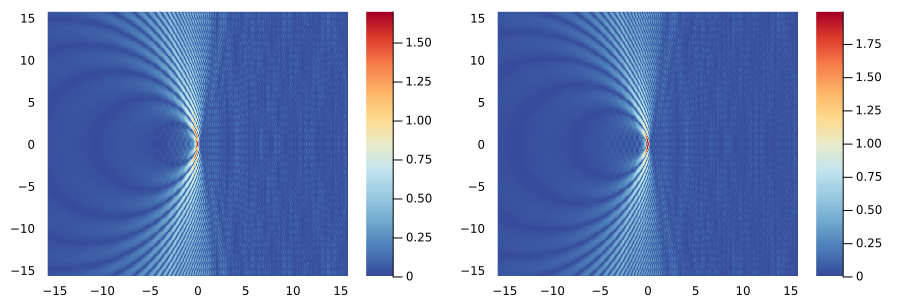

In [112]:
plot(heatmap(x_vals,x_vals,mod_grad_real),heatmap(x_vals,x_vals,mod_grad_imag),size=(900,300))

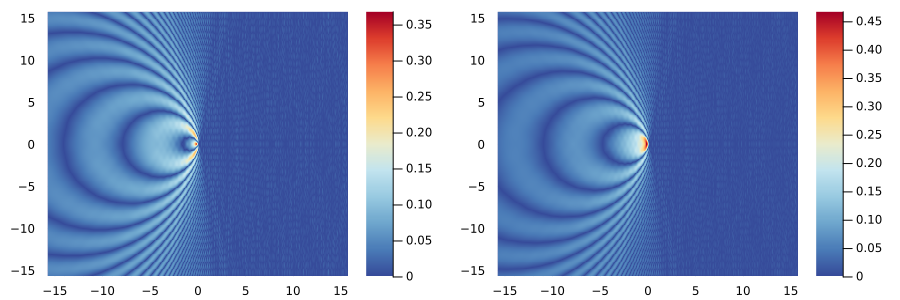

In [113]:
plot(heatmap(x_vals,x_vals,mod_real),heatmap(x_vals,x_vals,mod_imag),size=(900,300))

In [120]:
# Remove the centre
lhs = -5pi
for yi in 1:301
    for xi in 1:301
        x = lhs + (xi-1)A[5]
        y = lhs + (yi-1)A[5]
        if x^2 + y^2 <= (pi^3)/4
            mod_real[yi,xi] = 0
            mod_imag[yi,xi] = 0
            mod_grad_real[yi,xi] = 0
            mod_grad_imag[yi,xi] = 0
            mod_grad[yi,xi] = 0
            mod_full[yi,xi] = 0
        end
    end
end


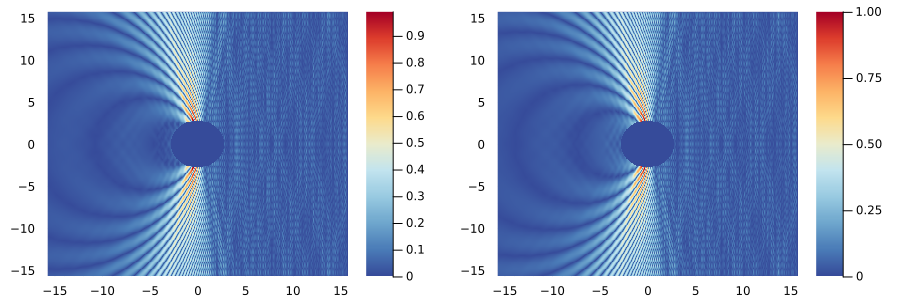

In [121]:
plot(heatmap(x_vals,x_vals,mod_grad_real),heatmap(x_vals,x_vals,mod_grad_imag),size=(900,300))

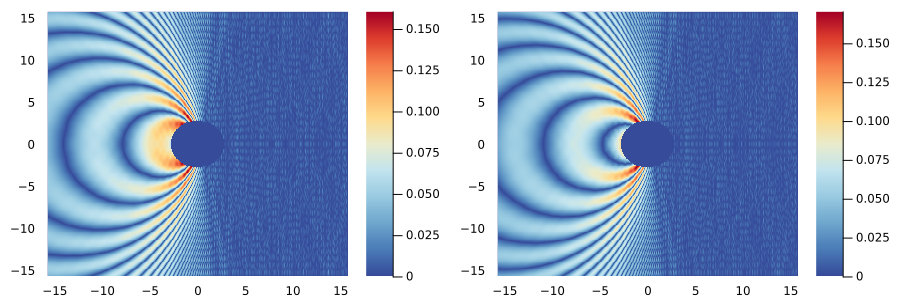

In [122]:
plot(heatmap(x_vals,x_vals,mod_real),heatmap(x_vals,x_vals,mod_imag),size=(900,300))

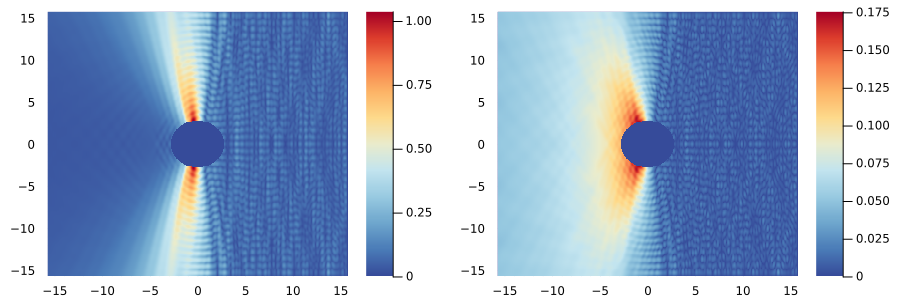

In [123]:
plot(heatmap(x_vals,x_vals,mod_grad),heatmap(x_vals,x_vals,mod_full),size=(900,300))

In [124]:
### maximum values

print(norm(mod_grad_real,Inf)/norm(mod_real,Inf),
    "\n",norm(mod_grad_imag,Inf)/norm(mod_imag,Inf),
    "\n",norm(mod_grad,Inf)/norm(mod_full,Inf))

6.17035888219367
5.872903754951525
5.907376239302405

#### Over subcritical velocities

In [125]:
max_grad = zeros(length(0:0.025:0.95))
real_check = zeros(length(0:0.025:0.95))
imag_check = zeros(length(0:0.025:0.95))
full = zeros(length(0:0.025:0.95))
velocity = zeros(length(0:0.025:0.95))
index = 1
for v in 0:0.025:0.95
    A = sub_ellipse(v,3pi/2,3pi/2,10pi,10pi,300,true,true)
    mod_grad_real = zeros(301,301)
    mod_grad_imag = zeros(301,301)
    mod_grad = zeros(301,301)
    mod_real = zeros(301,301)
    mod_imag = zeros(301,301)
    for xi in 2:300
        for yi in 2:300
            hx_r = first_centred_x(A[3],A[5],yi,xi)
            hy_r = first_centred_y(A[3],A[5],yi,xi)
            hx_i = first_centred_x(A[4],A[5],yi,xi)
            hy_i = first_centred_y(A[4],A[5],yi,xi)
            mod_grad_real[yi,xi] = sqrt(hx_r^2+hy_r^2)
            mod_grad_imag[yi,xi] = sqrt(hx_i^2+hy_i^2)
            mod_grad[yi,xi] = sqrt(hx_r^2+hx_i^2+hy_r^2+hy_i^2)
            mod_real[yi,xi] = abs(A[3][yi,xi])
            mod_imag[yi,xi] = abs(A[4][yi,xi])
        end
    end
    # yoink out the middle since it is a delta approximation
    lhs = -5pi
    for yi in 1:301
        for xi in 1:301
            x = lhs + (xi-1)A[5]
            y = lhs + (yi-1)A[5]
            if x^2 + y^2 <= (pi^3)/4
                mod_real[yi,xi] = 0
                mod_imag[yi,xi] = 0
                mod_grad_real[yi,xi] = 0
                mod_grad_imag[yi,xi] = 0
                mod_grad[yi,xi] = 0
                mod_full[yi,xi] = 0
            end
        end
    end
    real_check[index] = norm(mod_grad_real,Inf)/norm(mod_real,Inf)
    imag_check[index] = norm(mod_grad_imag,Inf)/norm(mod_imag,Inf)
    full[index] = norm(mod_grad,Inf)/norm(mod_full,Inf)
    # check the largest value
    max_grad[index] = norm(mod_grad,Inf)
    velocity[index] = v
    index += 1
    print(v, "\t")
end

0.0	0.025	0.05	0.075	0.1	0.125	0.15	0.175	0.2	0.225	0.25	0.275	0.3	0.325	0.35	0.375	0.4	0.425	0.45	0.475	0.5	0.525	0.55	0.575	0.6	0.625	0.65	0.675	0.7	0.725	0.75	0.775	0.8	0.825	0.85	0.875	0.9	0.925	0.95	

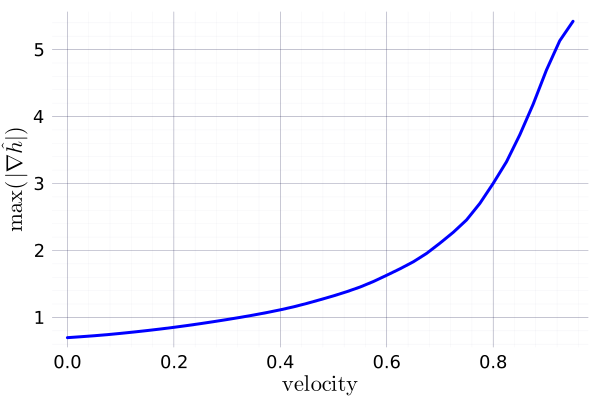

In [128]:
plot(velocity, full,
        xlabel=L"\textrm{velocity}",ylabel=L"\max(\,|\nabla\hat{h}\,|)",
        labelfontsize=15,tickfontsize=12,linewidth=3,legend=false,
        color="blue",gridalpha=0.5)